In [1]:
from src.mesh import Mesh3D
import numpy as np
from skimage.measure import marching_cubes
import pyvista as pv
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
euler_cube = np.load('./output/euler_cube.npy')
coord_cube = np.load('./output/coord_cube.npy')
Nb_cube = np.load('./output/Nb_cube.npy')
Sn_cube = np.load('./output/Sn_cube.npy')
points = np.load('./output/points.npy')
euler_flat = np.load('./output/euler_flat.npy')
Sn_flat = np.load('./output/Sn_flat.npy')
Nb_flat = np.load('./output/Nb_flat.npy')
Sn_points = np.copy(points)
phase_flat = np.load('./output/phase_flat.npy')

In [3]:
"""Find the vacuum interface"""


total_xray_cube = Nb_cube + Sn_cube
total_xray_cube = np.pad(total_xray_cube, pad_width=10, mode='edge')
Nb_cube = np.pad(Nb_cube, pad_width=10, mode='edge')

verts, faces, normals, values = marching_cubes(total_xray_cube,120000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
surface_mesh = pv.PolyData.from_regular_faces(verts, faces).subdivide(1).smooth(n_iter=10, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

verts, faces, normals, values = marching_cubes(Nb_cube,165000,spacing=(0.1,0.1,0.1))
verts = verts - np.array((1.0,1.0,1.0))
substrate_mesh = pv.PolyData.from_regular_faces(verts, faces).smooth(n_iter=20, relaxation_factor=0.1, boundary_smoothing=False).compute_normals(auto_orient_normals=True).triangulate()

"""Find points in vacuum"""
points_pv = pv.PolyData(points)
outside_points = points_pv.select_enclosed_points(surface_mesh.extrude([-10.0,0.0,0.0], capping=True), inside_out=True)
outside_mask = outside_points['SelectedPoints'].view(np.bool_)

phase_flat[outside_mask] = 3    # 3 -> Vacuum

point_data = {
    "euler": euler_flat,
    "phase": phase_flat
}

bounds = np.array(((0.0, 0.1*coord_cube.shape[0]),
        (0.0, 0.1*coord_cube.shape[1]),
        (0.0, 0.1*coord_cube.shape[2])))

mesh = Mesh3D(points, point_data, bounds)

/home/vike/dev/3debsd/.venv/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_array is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


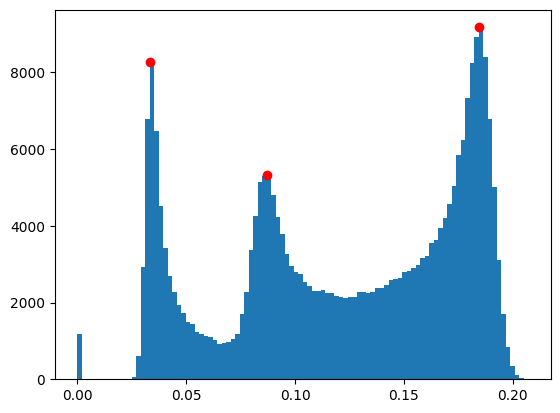

In [4]:
counts, bin_edges, patches = plt.hist(Sn_flat / (Nb_flat + Sn_flat + 1), bins=100)
peaks, _ = find_peaks(counts, height=4000)
plt.scatter(bin_edges[peaks], counts[peaks], c="red")
lower_Sn_peak, _, upper_Sn_peak = bin_edges[peaks]

In [38]:
grain_phases = np.array([arr[0] if arr.size > 0 else 0 for arr in mesh.grain_phase])
heterophase_faces = np.logical_and(mesh.T_FG[:, np.where(grain_phases == 2, True, False)].sum(axis = 1), mesh.T_FG[:, np.where(grain_phases != 2, True, False)].sum(axis = 1))
nb_interface = np.logical_and(mesh.T_FG[:, np.where(grain_phases == 1, True, False)].sum(axis = 1), heterophase_faces)

In [39]:

GB_vertices = [mesh.vor.ridge_vertices[face] for face in nb_interface.nonzero()[0]]

# First, identify which vertices are actually used in GB_vertices
used_vertices = set()
for triangle in GB_vertices:
    for idx in triangle:
        used_vertices.add(idx)

# Create a mapping from old indices to new indices
old_to_new = {}
new_vertices = []

for i, idx in enumerate(sorted(used_vertices)):
    old_to_new[idx] = i
    new_vertices.append(mesh.vertices[idx])

# Convert vertices to numpy array
new_vertices = np.array(new_vertices)

# Update the indices in GB_vertices
new_GB_vertices = []
for triangle in GB_vertices:
    new_triangle = [old_to_new[idx] for idx in triangle]
    new_GB_vertices.append(new_triangle)

grain_mesh = pv.PolyData.from_irregular_faces(new_vertices, new_GB_vertices).connectivity('largest').triangulate().clean().compute_normals(auto_orient_normals=True)  

In [ ]:
plotter = pv.Plotter()

grain_mesh.rotate_y(-90).elevation().plot(cmap="terrain")

plotter.view_xy()
plotter.show()

Widget(value='<iframe src="http://localhost:42439/index.html?ui=P_0x78ba4977f610_14&reconnect=auto" class="pyv…

Widget(value='<iframe src="http://localhost:42439/index.html?ui=P_0x78ba5493bc50_13&reconnect=auto" class="pyv…

In [60]:
points = grain_mesh.rotate_y(-90).rotate_z(-90).points
x = points[:, 0]
y = points[:, 1]
z = points[:, 2]

x = x[z <= 2.0]
y = y[z <= 2.0]
z = z[z <= 2.0]

from scipy.interpolate import griddata

# Create a grid covering the mesh XY extent
xi = np.linspace(x.min(), x.max(), 500)
yi = np.linspace(y.min(), y.max(), 500)
xi, yi = np.meshgrid(xi, yi)

# Interpolate z-values onto the grid
zi = griddata((x, y), z, (xi, yi), method='linear')


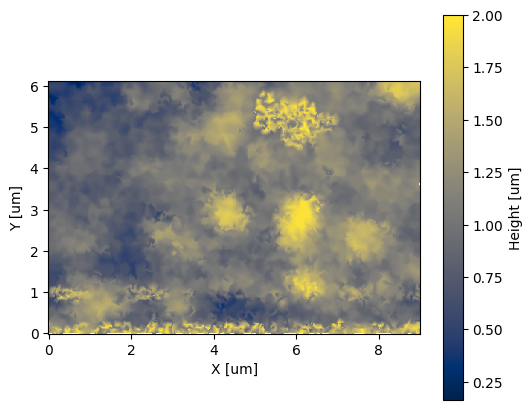

In [61]:
fig = plt.figure(figsize=(6,5))
plt.pcolormesh(xi, yi, zi, cmap='cividis', shading='auto')
plt.colorbar(label='Height [um]')
plt.xlabel('X [um]')
plt.ylabel('Y [um]')
fig.axes[0].set_aspect("equal", "box")
plt.show()
